In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("layoffs.csv")

In [3]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Lastminute,"Amsterdam, Non-U.S.",400.0,6/17/2026,0.25,Travel,https://res.cloudinary.com/lastminute-contenth...,Post-IPO,NaN,Netherlands,6/19/2026
1,Optimove,"Tel Aviv, Non-U.S.",NaN,6/17/2026,0.10,Marketing,https://www.intergameonline.com/igaming/news/o...,Series A,20.0,Israel,6/19/2026
2,Robinhood,SF Bay Area,290.0,6/16/2026,0.10,Finance,https://www.forbes.com/sites/tylerroush/2026/0...,Post-IPO,6200.0,United States,6/16/2026
3,Artlist,"Tel Aviv, Non-U.S.",200.0,6/16/2026,0.40,Media,https://www.calcalistech.com/ctechnews/article...,Unknown,48.0,Israel,6/16/2026
4,FNZ,"London, Non-U.S.",NaN,6/16/2026,NaN,Finance,https://citywire.com/new-model-adviser/news/ex...,Private Equity,3500.0,United Kingdom,6/16/2026


In [4]:
df.shape

(4469, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4469 entries, 0 to 4468
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4469 non-null   object 
 1   location             4468 non-null   object 
 2   total_laid_off       2928 non-null   float64
 3   date                 4469 non-null   object 
 4   percentage_laid_off  2806 non-null   float64
 5   industry             4467 non-null   object 
 6   source               4466 non-null   object 
 7   stage                4464 non-null   object 
 8   funds_raised         3948 non-null   float64
 9   country              4467 non-null   object 
 10  date_added           4469 non-null   object 
dtypes: float64(3), object(8)
memory usage: 384.2+ KB


In [6]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1541
date                      0
percentage_laid_off    1663
industry                  2
source                    3
stage                     5
funds_raised            521
country                   2
date_added                0
dtype: int64

In [7]:
(df.isnull().sum()/len(df))*100

company                 0.000000
location                0.022376
total_laid_off         34.481987
date                    0.000000
percentage_laid_off    37.211904
industry                0.044753
source                  0.067129
stage                   0.111882
funds_raised           11.658089
country                 0.044753
date_added              0.000000
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2928.000000,2806.000000,3948.000000
mean,315.802596,0.292754,867.233509
std,1193.797084,0.302919,4565.769163
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,176.000000
75%,200.000000,0.330000,484.000000
max,30000.000000,1.000000,121900.000000


In [10]:
df[df["total_laid_off"].isna()&
    df["percentage_laid_off"].isna()].shape

(727, 11)

In [11]:
df=df.dropna(subset=["total_laid_off","percentage_laid_off"], how="all")

In [12]:
df.shape

(3742, 11)

In [13]:
df["date"]=pd.to_datetime(df["date"])
df["date_added"]=pd.to_datetime(df["date_added"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3742 entries, 0 to 4468
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              3742 non-null   object        
 1   location             3741 non-null   object        
 2   total_laid_off       2928 non-null   float64       
 3   date                 3742 non-null   datetime64[ns]
 4   percentage_laid_off  2806 non-null   float64       
 5   industry             3740 non-null   object        
 6   source               3742 non-null   object        
 7   stage                3738 non-null   object        
 8   funds_raised         3320 non-null   float64       
 9   country              3740 non-null   object        
 10  date_added           3742 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 350.8+ KB


In [15]:
country_layoffs = df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False)
country_layoffs.head(10)

country
United States     657891.0
India              66289.0
Germany            32055.0
United Kingdom     24594.0
Netherlands        21975.0
Sweden             20379.0
Canada             16068.0
Israel             14819.0
Brazil             11939.0
China               8190.0
Name: total_laid_off, dtype: float64

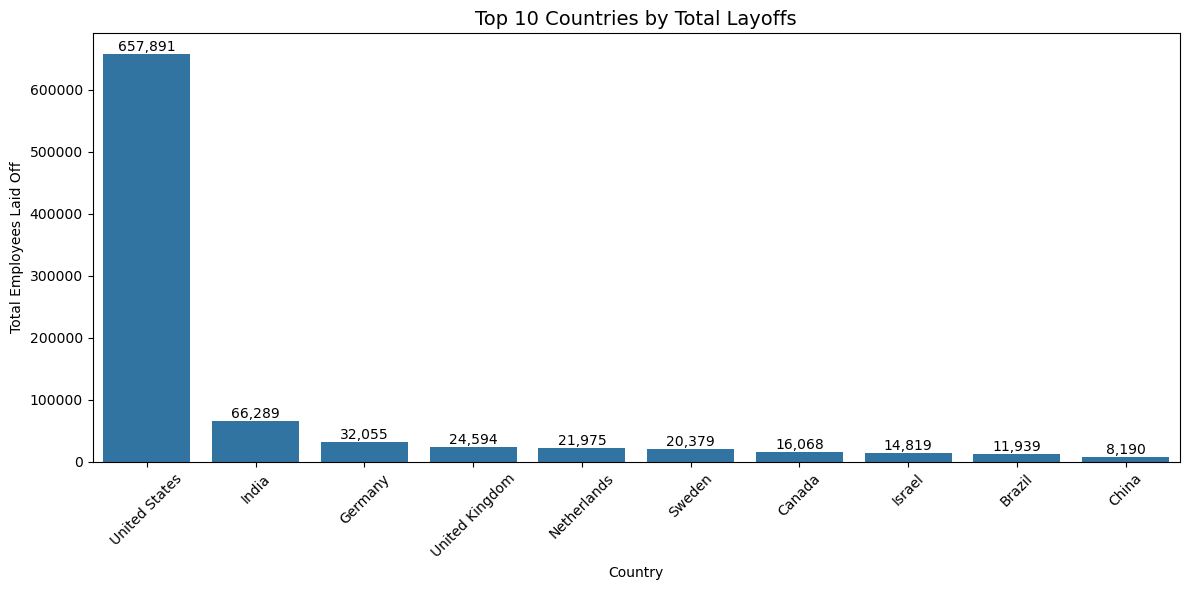

In [16]:
# Top 10 Countries by Total Layoffs
country_layoffs = (
    df.groupby("country")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=country_layoffs.index,
    y=country_layoffs.values)
plt.title("Top 10 Countries by Total Layoffs", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Total Employees Laid Off")
plt.xticks(rotation=45)
for i, value in enumerate(country_layoffs.values):
    ax.text(
        i,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom" )

plt.tight_layout()
plt.show()

### 📌 Key Insights

- United States recorded the highest number of layoffs, exceeding (***650,000***) employees.
- India ranks second with around (**66,000**) layoffs.
- There is a significant gap between the United States and all other countries.
- Germany, United Kingdom, and Netherlands occupy the next positions.
- Layoffs are heavily concentrated in a few countries, particularly the United States.

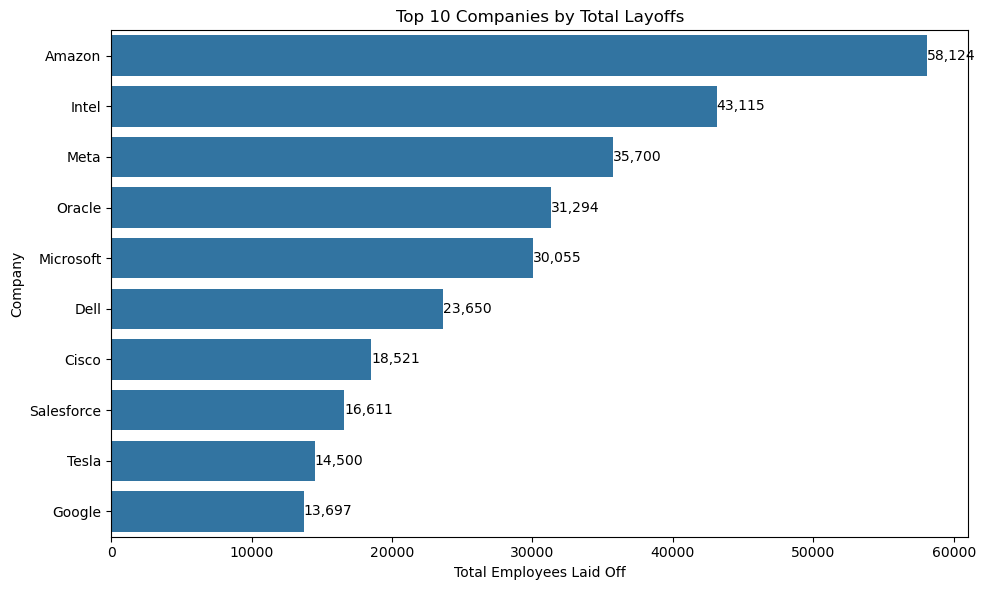

In [17]:
company_layoffs = (
    df.groupby("company")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=company_layoffs.values,
    y=company_layoffs.index
)

plt.title("Top 10 Companies by Total Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Company")

for i, v in enumerate(company_layoffs.values):
    ax.text(v, i, f"{int(v):,}", va='center')

plt.tight_layout()
plt.show()

### 📌 Key Insights

- Amazon recorded the highest total layoffs among all companies in the dataset, with **58,124** employees laid off.
- Intel ranked second with **43,115** layoffs, followed by Meta (**35,700**) and Oracle (**31,294**).
- Several global technology companies, including Microsoft, Google, Cisco, Salesforce, and Dell, appear in the top 10, indicating that the technology sector experienced significant workforce reductions.
- There is a noticeable gap between Amazon and the remaining companies, suggesting that Amazon was disproportionately affected compared to its peers.
- The results highlight that even well-established multinational companies implemented large-scale layoffs during the observed period, reflecting broader economic and industry-wide challenges.

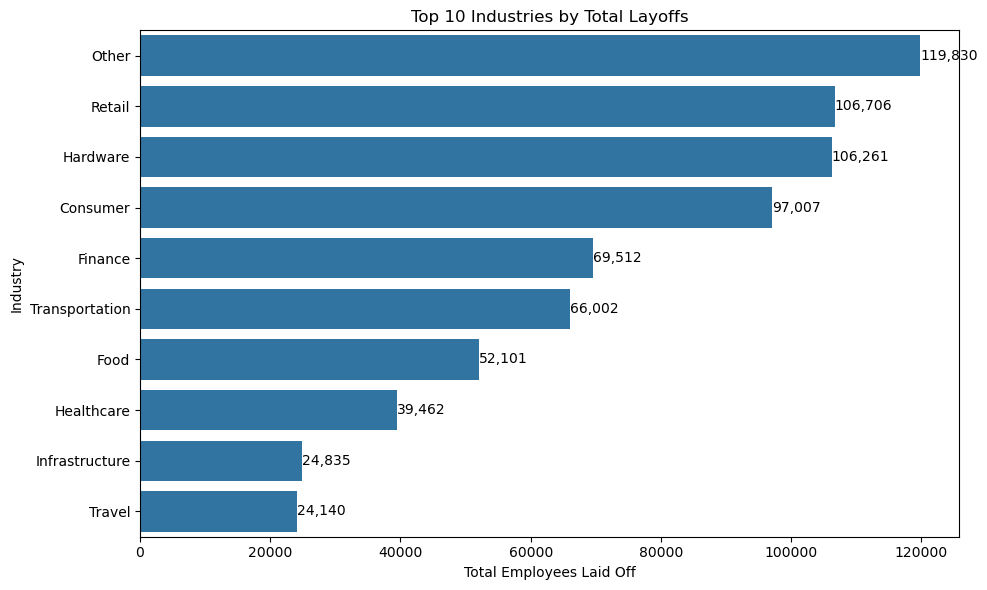

In [18]:
industry_layoffs = (
    df.groupby("industry")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=industry_layoffs.values,
    y=industry_layoffs.index)

plt.title("Top 10 Industries by Total Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Industry")

for i, v in enumerate(industry_layoffs.values):
    ax.text(v, i, f"{int(v):,}", va='center')

plt.tight_layout()
plt.show()

### 📌Key Insights

- The **"Other"** category recorded the highest layoffs (**119,830**), indicating that many companies belong to miscellaneous industries.
- Among specific industries, **Retail (106,706)** and **Hardware (106,261)** experienced the highest layoffs, showing that these sectors were heavily affected.
- **Consumer (97,007)** and **Finance (69,512)** also witnessed significant workforce reductions.
- **Travel (24,140)** and **Infrastructure (24,835)** reported the lowest layoffs among the top 10 industries.
- Overall, layoffs were concentrated mainly in **Retail, Hardware, Consumer, and Finance** sectors.

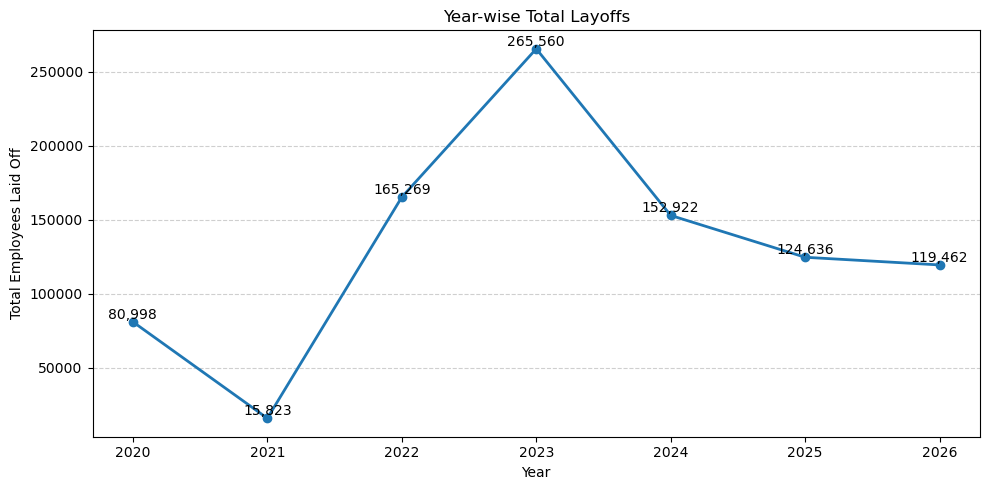

In [19]:
yearly_layoffs = (
    df.groupby(df["date"].dt.year)["total_laid_off"]
    .sum()
)
plt.figure(figsize=(10,5))

plt.plot(
    yearly_layoffs.index,
    yearly_layoffs.values,
    marker='o',
    linewidth=2)

for x, y in zip(yearly_layoffs.index, yearly_layoffs.values):
    plt.text(x, y, f"{int(y):,}", ha='center', va='bottom')

plt.title("Year-wise Total Layoffs")
plt.xlabel("Year")
plt.ylabel("Total Employees Laid Off")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 📌Key Insights

- Total layoffs were relatively low in **2021 (15,823)** compared to other years.
- Layoffs increased sharply in **2022 (165,269)** and reached their highest level in **2023 (265,560)**.
- After 2023, layoffs started to decline, with **2024 (152,922)**, **2025 (124,636)**, and **2026 (119,462)** showing a downward trend.
- Despite the decline, layoffs in 2024–2026 remained higher than the levels seen in 2020 and 2021.
- Overall, **2023 was the peak year for layoffs**, followed by a gradual recovery in the following years.

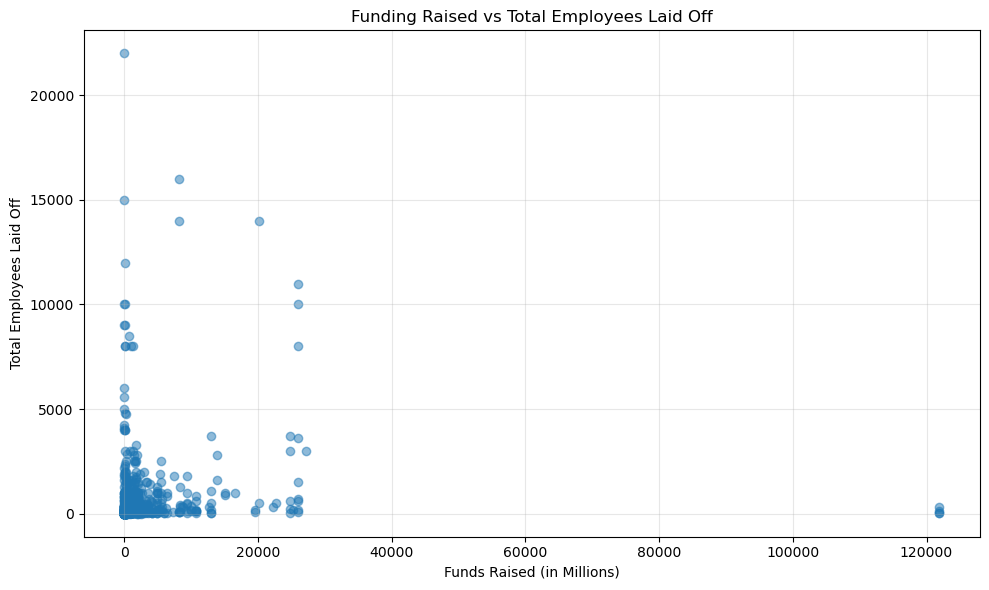

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["funds_raised"],
    df["total_laid_off"],
    alpha=0.5
)
plt.title("Funding Raised vs Total Employees Laid Off")
plt.xlabel("Funds Raised (in Millions)")
plt.ylabel("Total Employees Laid Off")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📌Key Insights

- Most companies raised **low to moderate funding** and also had **relatively fewer layoffs**, as shown by the dense cluster near the origin.
- There is **no strong linear relationship** between funding raised and the number of employees laid off.
- A few companies with **very high funding** still conducted layoffs, indicating that higher funding does not necessarily prevent workforce reductions.
- Several **outliers** are present, showing companies with either exceptionally high funding or unusually large layoffs.
- Overall, **funding alone is not a reliable indicator** of the number of employees laid off.

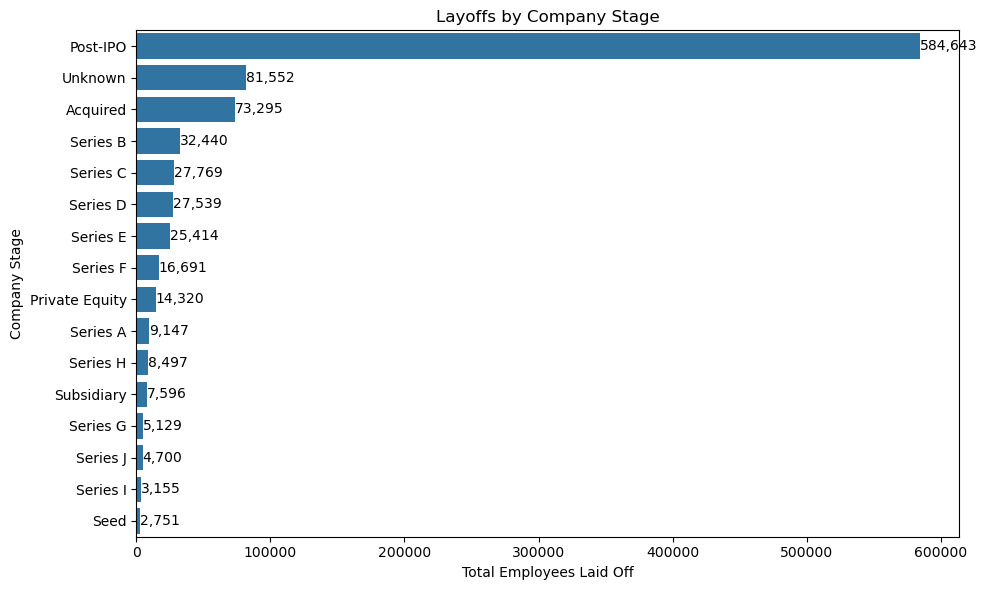

In [21]:
stage_layoffs = (
    df.groupby("stage")["total_laid_off"]
    .sum()
    .sort_values(ascending=False))

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=stage_layoffs.values,
    y=stage_layoffs.index
)
plt.title("Layoffs by Company Stage")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Company Stage")

for i, v in enumerate(stage_layoffs.values):
    ax.text(v, i, f"{int(v):,}", va='center')

plt.tight_layout()
plt.show()

### 📌Key Insights

- Most companies raised **low to moderate funding** and also had **relatively fewer layoffs**, as shown by the dense cluster near the origin.
- There is **no strong linear relationship** between funding raised and the number of employees laid off.
- A few companies with **very high funding** still conducted layoffs, indicating that higher funding does not necessarily prevent workforce reductions.
- Several **outliers** are present, showing companies with either exceptionally high funding or unusually large layoffs.
- Overall, **funding alone is not a reliable indicator** of the number of employees laid off.

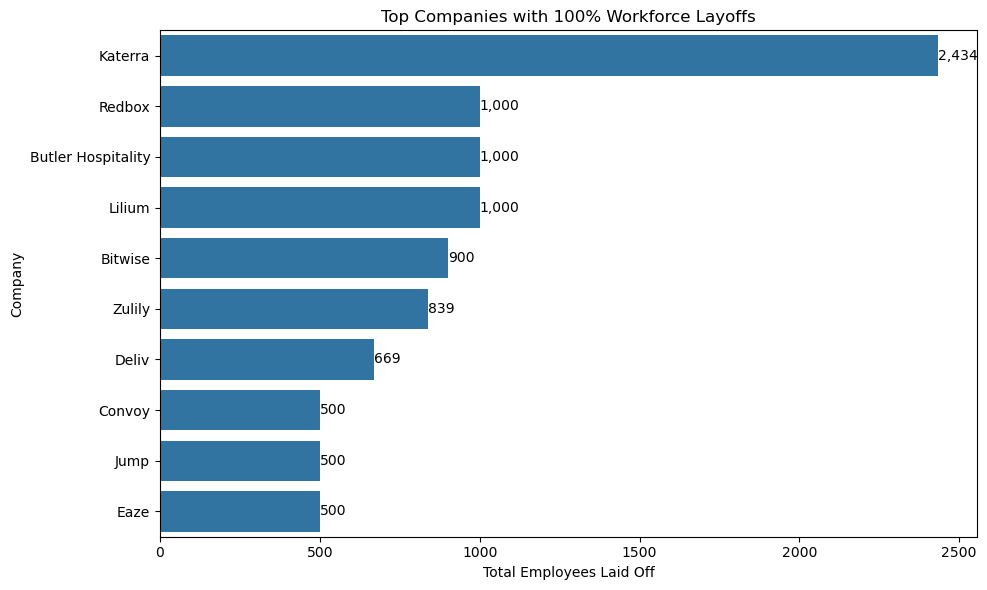

In [22]:
full_layoffs = (
    df[df["percentage_laid_off"] == 1]
    .groupby("company")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=full_layoffs.values,
    y=full_layoffs.index)
plt.title("Top Companies with 100% Workforce Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Company")

for i, v in enumerate(full_layoffs.values):
    ax.text(v, i, f"{int(v):,}", va='center')

plt.tight_layout()
plt.show()

### 📌Key Insights

- Most companies raised **low to moderate funding** and also had **relatively fewer layoffs**, as shown by the dense cluster near the origin.
- There is **no strong linear relationship** between funding raised and the number of employees laid off.
- A few companies with **very high funding** still conducted layoffs, indicating that higher funding does not necessarily prevent workforce reductions.
- Several **outliers** are present, showing companies with either exceptionally high funding or unusually large layoffs.
- Overall, **funding alone is not a reliable indicator** of the number of employees laid off.